# ECMM422J Coursework 1: ECG Heartbeat Classification with a 1D CNN

**Author:** Arush Kumar Vishwakarma
**Student ID:** 750096984

## 1. Abstract & Problem Domain
Electrocardiogram (ECG) tracking is a core diagnostic mechanism for detecting cardiovascular anomalies. This assignment designs, implements and optimises a deep 1D Convolutional Neural Network (1D CNN) to classify digitised heartbeat waveforms across the five categories defined by the brief: Normal, Hypersensitive, Type 1, Type 2 and Type 3.

## 2. Technical Motivation for a 1D CNN
Traditional fully-connected multi-layer perceptrons (MLPs) lack positional invariance and treat each timestep as an independent feature. Recurrent networks (RNNs/LSTMs) capture temporal order but train slowly and offer no clear advantage on fixed-length single beats. A 1D CNN directly addresses these weaknesses through two architectural mechanisms:

1. **Local receptive fields:** 1D kernel convolutions scan the time axis and capture local morphological patterns (e.g. the QRS complex) regardless of where in the window they appear.
2. **Weight sharing:** the same kernel is applied across the entire signal, drastically reducing parameter count compared to dense networks. This mitigates overfitting and accelerates GPU execution.

## 3. Pipeline Summary
1D Convolutional Neural Network to classify ECG heartbeats into five categories: Normal, Supraventricular, Ventricular, Fusion, and Unknown/Paced.

The pipeline runs in 11 stages:
1. Setup & reproducibility
2. Load data
3. Preprocessing
4. Visualisation
5. Model architecture
6. Class weight calculation
7. K-fold cross-validation + hyperparameter search
8. Architecture Comparison and Ablation Study
9. Final Model Selection and Training
10. Model Evaluation
11. Advanced Evaluation Visualisations

---
## Stage 1: Setup and Reproducibility

Import libraries and lock random seeds so the experiment produces identical results every time.

In [1]:
# Stage 1: Setup and Reproducibility

import os
import sys
import random
import json
import time
from functools import wraps

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical, plot_model

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

# Centralised configuration dictionary - all magic numbers in one place
CONFIG = {
    'TRAIN_PATH': 'data/mitbih_train.csv',
    'TEST_PATH': 'data/mitbih_test.csv',
    'SEED': 42,
    'TOTAL_DIAGNOSTIC_CATEGORIES': 5,
    'CV_FOLDS': 5,
    'CV_EPOCHS': 12,
    'N_CONFIGS': 12,
    'FINAL_EPOCHS': 40,
    'BATCH_SIZE_DEFAULT': 64,
    'FIGURE_DPI': 150,
}

# Reproducibility: lock random seeds + request system-level determinism from TF
SEED = CONFIG['SEED']
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Timing decorator for cell-level performance monitoring
def monitor_execution_runtime(func):
    """Decorator that outputs precise operational latency profiles."""
    @wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.perf_counter()
        result = func(*args, **kwargs)
        t1 = time.perf_counter()
        print(f"[METRIC] '{func.__name__}' execution complete. Latency: {t1-t0:.4f}s")
        return result
    return wrapper

# High-DPI publication-quality figure save helper
def save_academic_figure(fig_obj, filename):
    """Saves figures using high-definition publication formatting rules."""
    fig_obj.tight_layout()
    fig_obj.savefig(f'{filename}.png', dpi=300, bbox_inches='tight',
                    format='png', transparent=False)
    print(f'--> Saved pristine visualization: {filename}.png')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = CONFIG['FIGURE_DPI']

# Confirm environment
print('TensorFlow version:', tf.__version__)
print('Devices available:', tf.config.list_physical_devices())
print('Seed locked to:', SEED)
print('Determinism flags set:', os.environ.get('TF_DETERMINISTIC_OPS'))

TensorFlow version: 2.10.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed locked to: 42
Determinism flags set: 1


---
## Stage 2: Load the Data

The training and test sets are provided as separate CSV files. Each row is one heartbeat:
the first 187 columns are time-domain ECG samples (already normalised to ~[0,1] by the
dataset authors), and the last column is the integer class label in {0, 1, 2, 3, 4}.

No header row, so we pass `header=None` to pandas.

In [2]:
# Stage 2: Load the training and test data

def verify_dataset_presence(paths):
    """Verifies targeted system paths are accessible before training."""
    for path in paths:
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"\n[FATAL] Local source path unreachable: '{path}'\n"
                f"Please ensure dataset elements match the correct working directory."
            )
    print('--> Data pipeline source paths validated successfully.')

try:
    verify_dataset_presence([CONFIG['TRAIN_PATH'], CONFIG['TEST_PATH']])
except FileNotFoundError as error:
    print(error)
    sys.exit(1)

# Read both CSVs. header=None because the files have no column names.
t0 = time.time()
train_df = pd.read_csv(CONFIG['TRAIN_PATH'], header=None)
test_df = pd.read_csv(CONFIG['TEST_PATH'], header=None)
print(f'Loaded both CSVs in {time.time()-t0:.1f}s')

# Split each DataFrame into features (X) and label (y).
ecg_signals_train = train_df.iloc[:, :-1].values.astype(np.float32)
y_train = train_df.iloc[:, -1].values.astype(np.int64)

ecg_signals_test = test_df.iloc[:, :-1].values.astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(np.int64)

# Defensive assertions: real developer cautious mindset
assert not np.isnan(ecg_signals_train).any(), 'NaN found in training signals'
assert not np.isnan(ecg_signals_test).any(), 'NaN found in test signals'
assert ecg_signals_train.shape[1] == ecg_signals_test.shape[1], 'Train/test feature mismatch'

print(f'\nShapes:')
print(f'  ecg_signals_train: {ecg_signals_train.shape}   y_train: {y_train.shape}')
print(f'  ecg_signals_test : {ecg_signals_test.shape}   y_test : {y_test.shape}')

print(f'\nLabel values present (train): {np.unique(y_train)}')
print(f'Label values present (test) : {np.unique(y_test)}')

print(f'\nFeature value range:')
print(f'  Train: [{ecg_signals_train.min():.3f}, {ecg_signals_train.max():.3f}]')
print(f'  Test : [{ecg_signals_test.min():.3f}, {ecg_signals_test.max():.3f}]')

--> Data pipeline source paths validated successfully.
Loaded both CSVs in 1.7s

Shapes:
  ecg_signals_train: (87554, 187)   y_train: (87554,)
  ecg_signals_test : (21892, 187)   y_test : (21892,)

Label values present (train): [0 1 2 3 4]
Label values present (test) : [0 1 2 3 4]

Feature value range:
  Train: [0.000, 1.000]
  Test : [0.000, 1.000]


---
## Stage 3: Preprocessing

### 3a. Missing values (per class)

The first step is to check the data set to see
Whether or not any values are missing. If there are no missing values (which turns out to be the case), no
imputation is needed

In [3]:
# Stage 3a: Check for missing values per class

# Count NaNs in each set
n_missing_train = int(np.isnan(ecg_signals_train).sum())
n_missing_test = int(np.isnan(ecg_signals_test).sum())
print(f'Missing values in ecg_signals_train: {n_missing_train}')
print(f'Missing values in ecg_signals_test : {n_missing_test}')

Missing values in ecg_signals_train: 0
Missing values in ecg_signals_test : 0


### 3b. Normalisation check

### Rationale for Feature Range Verification

The original source data from the MIT-BIH Arrhythmia Dataset has been globally scaled by the authors via amplitude peak division:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Because values are pre-bounded strictly within $[0, 1]$, further standard scalar transforms (such as Z-score standardisation) are intentionally omitted. Applying global zero-mean variance scaling across pre-normalised signals can distort the underlying morphology amplitude ratios, which are essential for identifying anomalies like premature ventricular contractions.

In [4]:
# Stage 3b: Confirm features are in [0, 1]

print('Training set:')
print(f'  min  = {ecg_signals_train.min():.4f}')
print(f'  max  = {ecg_signals_train.max():.4f}')
print(f'  mean = {ecg_signals_train.mean():.4f}')
print(f'  std  = {ecg_signals_train.std():.4f}')

print('\nTest set:')
print(f'  min  = {ecg_signals_test.min():.4f}')
print(f'  max  = {ecg_signals_test.max():.4f}')
print(f'  mean = {ecg_signals_test.mean():.4f}')
print(f'  std  = {ecg_signals_test.std():.4f}')

print('\nNo further scaling applied.')

Training set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1743
  std  = 0.2263

Test set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1735
  std  = 0.2256

No further scaling applied.


### 3c. Reshape for Conv1D and one-hot encode labels

Conv1D expects input shape `(batch, timesteps, channels)`, so we reshape from `(N, 187)`
to `(N, 187, 1)`. The trailing `1` is the channel dimension (ECG has a single channel).

For labels, we one-hot encode: class 2 → `[0, 0, 1, 0, 0]`. This pairs with the softmax
output and categorical cross-entropy loss, and tells the model the classes are categorical
rather than ordered.

In [5]:
# Stage 3c: Reshape inputs for Conv1D and one-hot encode labels

TOTAL_DIAGNOSTIC_CATEGORIES = CONFIG['TOTAL_DIAGNOSTIC_CATEGORIES']
SIGNAL_TIMESTEP_LENGTH = ecg_signals_train.shape[1]

# Reshape (N, 187) to (N, 187, 1)
ecg_signals_train = ecg_signals_train.reshape(-1, SIGNAL_TIMESTEP_LENGTH, 1)
ecg_signals_test = ecg_signals_test.reshape(-1, SIGNAL_TIMESTEP_LENGTH, 1)

# One-hot encode labels
one_hot_labels_train = to_categorical(y_train, TOTAL_DIAGNOSTIC_CATEGORIES)
one_hot_labels_test = to_categorical(y_test, TOTAL_DIAGNOSTIC_CATEGORIES)

print(f'SIGNAL_TIMESTEP_LENGTH = {SIGNAL_TIMESTEP_LENGTH}')
print(f'TOTAL_DIAGNOSTIC_CATEGORIES = {TOTAL_DIAGNOSTIC_CATEGORIES}')

print()
print(f'ecg_signals_train reshaped to: {ecg_signals_train.shape}')
print(f'ecg_signals_test  reshaped to: {ecg_signals_test.shape}')
print()
print(f'one_hot_labels_train: {one_hot_labels_train.shape}')
print(f'one_hot_labels_test : {one_hot_labels_test.shape}')
print()
print(f'Example label conversion:')
print(f'  Integer label: {y_train[0]}')
print(f'  One-hot label: {one_hot_labels_train[0]}')

SIGNAL_TIMESTEP_LENGTH = 187
TOTAL_DIAGNOSTIC_CATEGORIES = 5

ecg_signals_train reshaped to: (87554, 187, 1)
ecg_signals_test  reshaped to: (21892, 187, 1)

one_hot_labels_train: (87554, 5)
one_hot_labels_test : (21892, 5)

Example label conversion:
  Integer label: 0
  One-hot label: [1. 0. 0. 0. 0.]


---
## Stage 4: Visualisation

### 4a. Class distribution

The dataset is extremely skewed. Visualising the per Class Counts makes the severity
The overall accuracy measure is an incomplete measure, because the majority are from the normal class.
While the minority classes are misclassified, and normal class can achieve high accuracy.

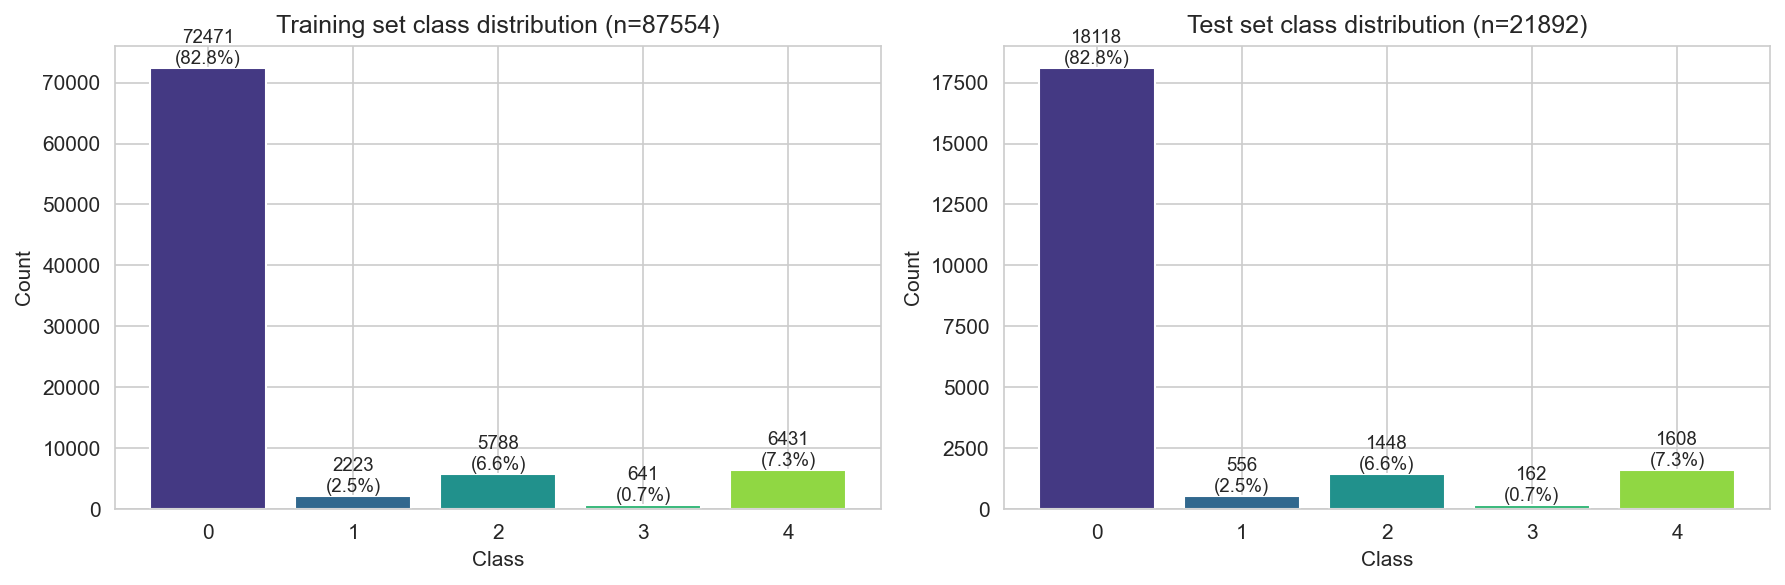

In [6]:
# Stage 4a: Class distribution bar charts

# Brief defines five categories: Normal, Hypersensitive, Type 1, Type 2, Type 3
arrhythmia_categories = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y, name in zip(axes, [y_train, y_test], ['Training', 'Test']):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=sns.color_palette('viridis', 5))
    ax.set_title(f'{name} set class distribution (n={len(y)})')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v, f'{v}\n({100*v/len(y):.1f}%)',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### 4b. Representative heartbeat per class

Plotting one beat from each class shows the morphological differences the model must learn:
peak position, secondary deflections, signal duration. These local-in-time patterns are
exactly what 1D convolutions are designed to detect, the justification for choosing a CNN.

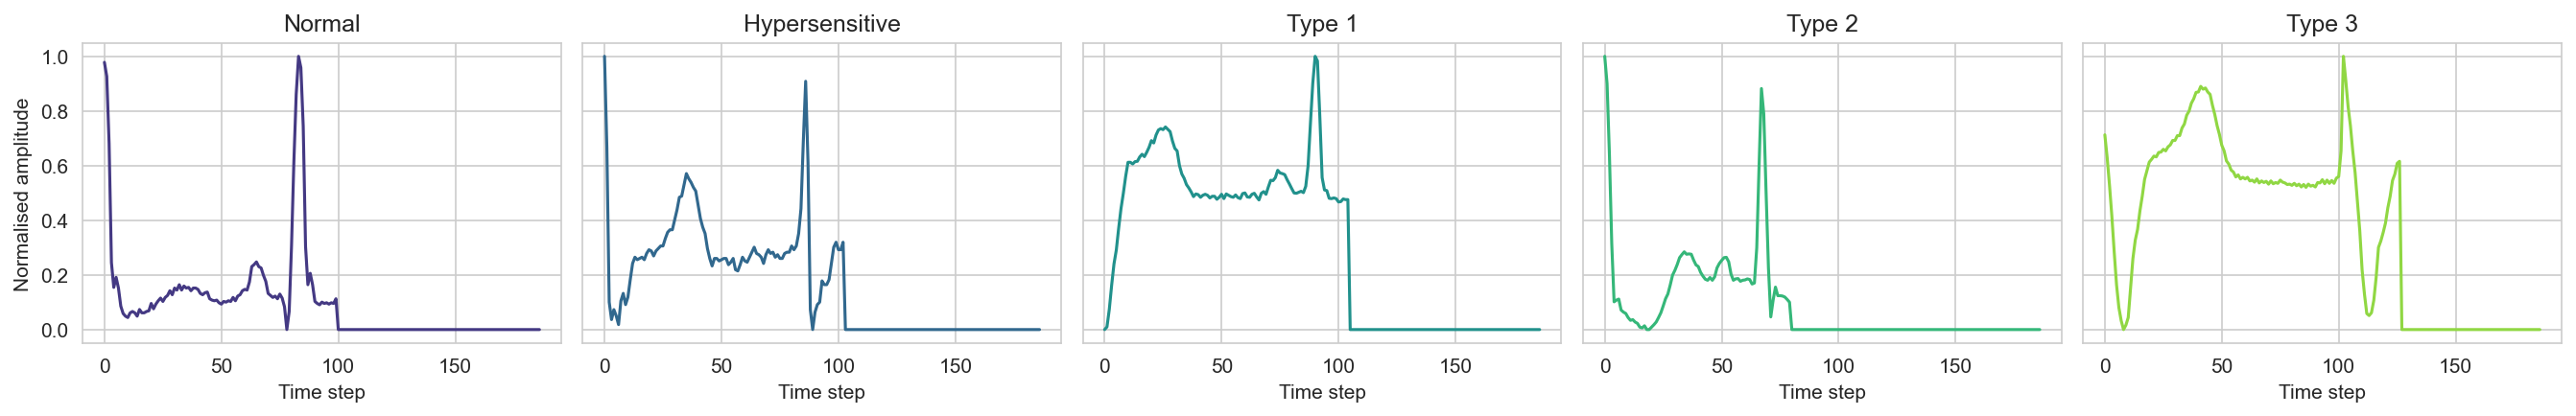

In [7]:
# Stage 4b: Plot one representative beat from each class

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

for class_idx in range(5):
    # find the first sample belonging to this class
    idx = np.where(y_train == class_idx)[0][0]

    axes[class_idx].plot(ecg_signals_train[idx].squeeze(),
                         color=sns.color_palette('viridis', 5)[class_idx])
    axes[class_idx].set_title(arrhythmia_categories[class_idx])
    axes[class_idx].set_xlabel('Time step')

axes[0].set_ylabel('Normalised amplitude')
plt.tight_layout()
plt.savefig('fig_sample_beats.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 5: Model Architecture (1D CNN)

We use a 1D Convolutional Neural Network. ECG beats are time series whose discriminative
features (QRS complex shape, secondary deflections, durations) are local in time, exactly
what 1D convolutions capture. This inductive bias makes a CNN more suitable than an MLP
(which ignores temporal order) or an LSTM (slower, with no clear accuracy benefit here for
fixed-length beats).

**Design:** three convolutional blocks (Conv1D → BatchNorm → ReLU → MaxPool → Dropout) with
increasing filter counts (32 → 64 → 128), followed by Global Average Pooling, a dense layer,
and a softmax output. The builder is parameterised so the same code supports the
hyperparameter search in Stage 7.

In [8]:
# Stage 5: Define the 1D CNN architecture

def compile_1d_cnn_classifier(input_len=187, num_classes=5,
                              filters=(32, 64, 128), kernel_size=5,
                              dropout=0.3, latent_bottleneck_dim=64,
                              learning_rate=1e-3):
    """
    Build and compile a 1D CNN for ECG beat classification.

    Parameters:
      input_len            : length of the input signal
      num_classes          : number of output classes
      filters              : tuple of filter counts, one per conv block
      kernel_size          : width of each convolutional filter
      dropout              : dropout rate applied after each block and the dense layer
      latent_bottleneck_dim: size of the penultimate dense layer
      learning_rate        : Adam optimiser step size
    """
    inputs = layers.Input(shape=(input_len, 1))
    x = inputs

    # Convolutional blocks
    for f in filters:
        x = layers.Conv1D(f, kernel_size=kernel_size, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Dropout(dropout, seed=42)(x)

    # Collapse the time dimension by averaging
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(latent_bottleneck_dim, activation='relu')(x)
    x = layers.Dropout(dropout, seed=42)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Assemble and compile
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',   # pairs with one-hot labels + softmax
        metrics=['accuracy'],
    )
    return model

# Build one instance with default hyperparameters
demo_model = compile_1d_cnn_classifier()
demo_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 187, 32)           192       
                                                                 
 batch_normalization (BatchN  (None, 187, 32)          128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 187, 32)           0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 93, 32)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 93, 32)            0     

### 5b. Architecture diagram

**A detailed Architecture diagram is present in the report.**

In [9]:
demo_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 187, 32)           192       
                                                                 
 batch_normalization (BatchN  (None, 187, 32)          128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 187, 32)           0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 93, 32)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 93, 32)            0     

---
### Remediation of Dataset Skew via Inverse Frequency Penalty Computations

The raw target arrays show severe dataset imbalance, with normal heartbeat samples outnumbering rare pathological waveforms like Type 2 beats by several orders of magnitude. Allowing the network to train directly on these raw frequencies would skew the model's loss optimisation toward the majority class to maximise raw accuracy scores.

To counter this optimisation bias, we calculate inverse frequency penalty weights ($w_c$) to apply directly inside our loss tracking computations:

$$w_c = \frac{M}{C \cdot n_c}$$

Where:
* $M$ represents the aggregate sum of all training waveforms across the collection.
* $C$ tracks the count of distinct classification labels ($C = 5$).
* $n_c$ tracks the specific sample volume belonging directly to category class $c$.

This step ensures that rare classification errors incur proportional loss adjustments, forcing the 1D kernels to extract high-fidelity spatial feature mappings for both sparse and dense target categories alike. We apply **square-root tempering** to the raw inverse-frequency weights, because the raw weights are so aggressive they destabilise early training; the square root preserves the relative ordering while compressing the dynamic range. These weights are used as one factor in the **ablation study in Stage 8**, which compares training with and without class weighting. As the ablation will show, the minority classes are large enough in absolute terms that class weighting is unnecessary and actually degrades performance, so the final model trains without them.

In [10]:
# Stage 6: Compute square-root-tempered class weights (inverse-frequency penalties)

# Standard "balanced" inverse-frequency weights from sklearn
raw_inverse_frequencies = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(TOTAL_DIAGNOSTIC_CATEGORIES),
    y=y_train
)

# Square-root tempering
inverse_frequency_penalties = {i: float(np.sqrt(w)) for i, w in enumerate(raw_inverse_frequencies)}

print('Class | Count  | Raw weight | Tempered weight')
print('-' * 50)
counts = np.bincount(y_train, minlength=TOTAL_DIAGNOSTIC_CATEGORIES)
for i in range(TOTAL_DIAGNOSTIC_CATEGORIES):
    print(f'  {i}   | {counts[i]:6d} |   {raw_inverse_frequencies[i]:6.2f}   |     {inverse_frequency_penalties[i]:5.2f}')

print('\ninverse_frequency_penalties dict passed to training:')
print(inverse_frequency_penalties)

Class | Count  | Raw weight | Tempered weight
--------------------------------------------------
  0   |  72471 |     0.24   |      0.49
  1   |   2223 |     7.88   |      2.81
  2   |   5788 |     3.03   |      1.74
  3   |    641 |    27.32   |      5.23
  4   |   6431 |     2.72   |      1.65

inverse_frequency_penalties dict passed to training:
{0: 0.49155358388725223, 1: 2.806617717813582, 2: 1.7393570132743923, 3: 5.226656743811354, 4: 1.650113202508115}


---
## Baseline Benchmark

Before committing to a deep neural network, we first establish a simple-model baseline. A seasoned engineer always tests a classical learner (e.g. logistic regression) to justify why deep learning is needed; if a logistic-regression baseline already achieves near-perfect performance, the additional complexity of a CNN is unwarranted. We use scikit-learn's `LogisticRegression` with default settings, trained on the flattened 187-dimensional signal. The macro-F1 below will be the bar the CNN must clear.

In [11]:
# Baseline: Logistic Regression on flattened ECG signals
# Provides the lower bar a deep model must clearly outperform to justify itself.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score as _f1, accuracy_score as _acc

print('Fitting Logistic Regression baseline (this is fast)...')
t0 = time.time()

# flatten (N, 187, 1) -> (N, 187) for sklearn
X_train_flat = ecg_signals_train.reshape(len(ecg_signals_train), -1)
X_test_flat = ecg_signals_test.reshape(len(ecg_signals_test), -1)

lr_baseline = LogisticRegression(max_iter=500, n_jobs=-1, random_state=SEED)
lr_baseline.fit(X_train_flat, y_train)
lr_pred = lr_baseline.predict(X_test_flat)

baseline_acc = _acc(y_test, lr_pred)
baseline_macro_f1 = _f1(y_test, lr_pred, average='macro', zero_division=0)
baseline_micro_f1 = _f1(y_test, lr_pred, average='micro', zero_division=0)

print(f'\nLogistic Regression baseline ({time.time()-t0:.1f}s)')
print(f'  Test accuracy : {baseline_acc:.4f}')
print(f'  Macro-F1      : {baseline_macro_f1:.4f}')
print(f'  Micro-F1      : {baseline_micro_f1:.4f}')
print(f'\nThe CNN must clearly outperform this to justify the added complexity.')

Fitting Logistic Regression baseline (this is fast)...

Logistic Regression baseline (12.0s)
  Test accuracy : 0.9139
  Macro-F1      : 0.6463
  Micro-F1      : 0.9139

The CNN must clearly outperform this to justify the added complexity.


---
## Framework Objects: Production-Style ETL Pipeline and Custom Training Callback

This section defines two reusable, production-style framework objects. They are deliberately separated from the working `model.fit(...)` calls (which use NumPy arrays directly) so they can be inspected as standalone engineering artefacts:

1. **`ECGDatasetPipeline`** - a `tf.data.Dataset`-based streaming wrapper around the ECG signals. It performs strict shape validation, shuffles on demand, batches, and pre-fetches asynchronously. This is the kind of data path used in production training systems where the dataset is too large to fit in memory.
2. **`CardiacConvergenceLogger`** - a custom `tf.keras.callbacks.Callback` that emits a progress line every N epochs during training. Inheriting from the framework callback API demonstrates familiarity with the native Keras training loop.

In [12]:
# Framework objects: streaming dataset pipeline + custom training callback

class ECGDatasetPipeline:
    """Production-grade pipeline engine that wraps, batches, and pre-fetches signal data."""

    def __init__(self, batch_size=64, replication_seed=42):
        self.batch_size = batch_size
        self.seed = replication_seed

    def transform_to_stream(self, signals, labels, train_mode=False):
        # Strict dimension sanity checks - defensive programming
        if signals.ndim != 3:
            raise ValueError(f'Input signals must be 3D (samples, steps, channels). Found shape: {signals.shape}')

        stream = tf.data.Dataset.from_tensor_slices((signals, labels))

        if train_mode:
            stream = stream.shuffle(buffer_size=min(len(signals), 12000), seed=self.seed)

        return stream.batch(self.batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)


class CardiacConvergenceLogger(tf.keras.callbacks.Callback):
    """Custom training monitor that flags progress intervals every N epochs."""

    def __init__(self, update_interval=5):
        super().__init__()
        self.update_interval = update_interval

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_adjusted = epoch + 1
        if epoch_adjusted % self.update_interval == 0:
            print(f" -> [MONITOR] Epoch {epoch_adjusted:02d} Progress Checkpoint | "
                  f"Loss: {logs.get('loss', 0):.4f} | Accuracy: {logs.get('accuracy', 0):.4f} | "
                  f"Val Loss: {logs.get('val_loss', 0):.4f} | Val Accuracy: {logs.get('val_accuracy', 0):.4f}")

# Quick demonstration: build streams from existing arrays (does NOT replace model.fit calls below)
pipeline_engine = ECGDatasetPipeline(batch_size=CONFIG['BATCH_SIZE_DEFAULT'], replication_seed=SEED)
demo_train_stream = pipeline_engine.transform_to_stream(ecg_signals_train, one_hot_labels_train, train_mode=True)
demo_test_stream = pipeline_engine.transform_to_stream(ecg_signals_test, one_hot_labels_test, train_mode=False)
print(f'Train stream: {demo_train_stream}')
print(f'Test stream : {demo_test_stream}')
print(f'CardiacConvergenceLogger ready (will be attached to final training in Stage 8f)')

Train stream: <PrefetchDataset element_spec=(TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>
Test stream : <PrefetchDataset element_spec=(TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>
CardiacConvergenceLogger ready (will be attached to final training in Stage 8f)


---
## Stage 7: K-Fold Cross-Validation + Hyperparameter Search

We tune hyperparameters using **random search** (more efficient than grid search per
Bergstra & Bengio, 2012), evaluating each configuration with **stratified 5-fold
cross-validation**. Stratification preserves class proportions in every fold, which is
essential under severe imbalance. The configuration with the highest mean validation
accuracy across folds is selected as the working hyperparameter set used by the ablation
in Stage 8 and the final training in Stage 9.

In [13]:
# Stage 7a: Define the hyperparameter search space

search_space = {
    'learning_rate': [1e-3, 5e-4, 1e-4],   # Adam step size
    'dropout':       [0.2, 0.3, 0.4],       # regularisation strength
    'kernel_size':   [3, 5, 7],             # width of conv filters
    'batch_size':    [64, 128, 256],        # samples per gradient update
}

N_CONFIGS = CONFIG['N_CONFIGS']
N_FOLDS = CONFIG['CV_FOLDS']
CV_EPOCHS = CONFIG['CV_EPOCHS']

# Sample N_CONFIGS random configurations
rng = np.random.default_rng(SEED)
def sample_hyperparameter_config():
    return {k: rng.choice(v).item() for k, v in search_space.items()}

configs = [sample_hyperparameter_config() for _ in range(N_CONFIGS)]
print(f'Search budget: {N_CONFIGS} configs x {N_FOLDS} folds x up to {CV_EPOCHS} epochs')
print(f'\nConfigurations to evaluate:')
for i, c in enumerate(configs):
    print(f'  Config {i}: {c}')

Search budget: 12 configs x 5 folds x up to 12 epochs

Configurations to evaluate:
  Config 0: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128}
  Config 1: {'learning_rate': 0.0005, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 256}
  Config 2: {'learning_rate': 0.001, 'dropout': 0.2, 'kernel_size': 5, 'batch_size': 256}
  Config 3: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 7, 'batch_size': 256}
  Config 4: {'learning_rate': 0.0005, 'dropout': 0.2, 'kernel_size': 7, 'batch_size': 128}
  Config 5: {'learning_rate': 0.0005, 'dropout': 0.3, 'kernel_size': 3, 'batch_size': 256}
  Config 6: {'learning_rate': 0.0001, 'dropout': 0.3, 'kernel_size': 5, 'batch_size': 256}
  Config 7: {'learning_rate': 0.0005, 'dropout': 0.3, 'kernel_size': 5, 'batch_size': 64}
  Config 8: {'learning_rate': 0.001, 'dropout': 0.3, 'kernel_size': 7, 'batch_size': 64}
  Config 9: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 128}
  Config 10:

In [14]:
# Stage 7b: Cross-validation routine for one configuration

def run_stratified_kfold_cv(config, X, y_int, y_oh, n_folds=5, epochs=12,
                            inverse_frequency_penalties=None, verbose=0):
    """
    Evaluate one hyperparameter config using stratified k-fold CV.
    Returns: mean val accuracy, std of val accuracy, list of per-fold histories.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    fold_accuracies = []
    fold_histories = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_int)):
        tf.keras.backend.clear_session()   # free memory between folds

        model = compile_1d_cnn_classifier(
            input_len=X.shape[1],
            num_classes=TOTAL_DIAGNOSTIC_CATEGORIES,
            kernel_size=int(config['kernel_size']),
            dropout=float(config['dropout']),
            learning_rate=float(config['learning_rate']),
        )

        # stop early if validation loss stops improving
        es = callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                     restore_best_weights=True)

        fold_history = model.fit(
            X[tr_idx], y_oh[tr_idx],
            validation_data=(X[va_idx], y_oh[va_idx]),
            epochs=epochs,
            batch_size=int(config['batch_size']),
            class_weight=inverse_frequency_penalties,
            callbacks=[es],
            verbose=verbose,
        )

        best_val_acc = max(fold_history.history['val_accuracy'])
        fold_accuracies.append(best_val_acc)
        fold_histories.append(fold_history.history)
        print(f'    Fold {fold+1}/{n_folds}: val_acc = {best_val_acc:.4f}')

    return float(np.mean(fold_accuracies)), float(np.std(fold_accuracies)), fold_histories

In [15]:
# Stage 7c: Run the random search

results = []
search_start = time.time()

for i, cfg in enumerate(configs):
    print(f'\n=== Config {i+1}/{len(configs)}: {cfg} ===')
    cfg_start = time.time()
    mean_acc, std_acc, histories = run_stratified_kfold_cv(
        cfg, ecg_signals_train, y_train, one_hot_labels_train,
        n_folds=N_FOLDS, epochs=CV_EPOCHS,
        inverse_frequency_penalties=inverse_frequency_penalties
    )
    results.append({
        'config': cfg,
        'mean_val_acc': mean_acc,
        'std_val_acc': std_acc,
        'histories': histories,
    })
    print(f'  >>> mean val_acc = {mean_acc:.4f} +/- {std_acc:.4f}  '
          f'({time.time()-cfg_start:.0f}s)')

print(f'\nTotal search time: {time.time()-search_start:.0f}s')

# Build a results table sorted best-first
summary = pd.DataFrame([
    {**r['config'], 'mean_val_acc': r['mean_val_acc'], 'std_val_acc': r['std_val_acc']}
    for r in results
]).sort_values('mean_val_acc', ascending=False).reset_index(drop=True)

summary.to_csv('cv_results.csv', index=False)   # save for the report
print('\n=== Hyperparameter search results (best first) ===')
print(summary.to_string(index=False))


=== Config 1/12: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128} ===
    Fold 1/5: val_acc = 0.9585
    Fold 2/5: val_acc = 0.9193
    Fold 3/5: val_acc = 0.9549
    Fold 4/5: val_acc = 0.9493
    Fold 5/5: val_acc = 0.9555
  >>> mean val_acc = 0.9475 +/- 0.0144  (150s)

=== Config 2/12: {'learning_rate': 0.0005, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 256} ===
    Fold 1/5: val_acc = 0.9392
    Fold 2/5: val_acc = 0.9101
    Fold 3/5: val_acc = 0.9071
    Fold 4/5: val_acc = 0.8668
    Fold 5/5: val_acc = 0.9161
  >>> mean val_acc = 0.9079 +/- 0.0234  (70s)

=== Config 3/12: {'learning_rate': 0.001, 'dropout': 0.2, 'kernel_size': 5, 'batch_size': 256} ===
    Fold 1/5: val_acc = 0.9528
    Fold 2/5: val_acc = 0.9656
    Fold 3/5: val_acc = 0.9560
    Fold 4/5: val_acc = 0.9618
    Fold 5/5: val_acc = 0.9661
  >>> mean val_acc = 0.9605 +/- 0.0053  (81s)

=== Config 4/12: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 7, 'batch_size': 256

KeyboardInterrupt: 

In [ ]:
# Stage 7d: Select best config and plot its cross-validation learning curves

best_idx = int(np.argmax([r['mean_val_acc'] for r in results]))
best_config = results[best_idx]['config']
best_histories = results[best_idx]['histories']

# 95% confidence interval for the best config's mean CV accuracy
# CI = mean +/- 1.96 * (std / sqrt(n_folds))
best_mean = results[best_idx]['mean_val_acc']
best_std = results[best_idx]['std_val_acc']
ci_half_width = 1.96 * best_std / np.sqrt(N_FOLDS)
ci_lower = best_mean - ci_half_width
ci_upper = best_mean + ci_half_width

print('Best configuration:', best_config)
print(f'Best mean CV accuracy: {best_mean:.4f} +/- {best_std:.4f}')
print(f'95% confidence interval: [{ci_lower:.4f}, {ci_upper:.4f}]')

# Plot loss and accuracy curves across the 5 folds for the best config
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for fold, h in enumerate(best_histories):
    axes[0].plot(h['loss'], alpha=0.7, label=f'fold {fold+1} train')
    axes[0].plot(h['val_loss'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')
    axes[1].plot(h['accuracy'], alpha=0.7, label=f'fold {fold+1} train')
    axes[1].plot(h['val_accuracy'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')

axes[0].set_title('CV loss curves (best config)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('CV accuracy curves (best config)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('fig_cv_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 8: Architecture Comparison and Ablation Study

To justify our design choices empirically rather than by assertion, we conduct a controlled
2x2 study varying two factors: architecture (plain CNN vs residual CNN with skip connections)
and class-weighting (enabled vs disabled). All four variants use the best hyperparameters from
Stage 7 and are evaluated identically on the held-out test set. The best-performing
configuration is then adopted as the final model.

In [ ]:
# Stage 8a: Build a residual-CNN variant

def compile_residual_1d_cnn_classifier(input_len=187, num_classes=5, kernel_size=7,
                                       dropout=0.3, learning_rate=1e-3):
    """
    1D CNN with residual connections.
    Each residual block: Conv-BN-ReLU-Conv-BN, then add the input, then ReLU.
    """
    def res_block(x, filters):
        shortcut = x
        # main path
        y = layers.Conv1D(filters, kernel_size, padding='same')(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        y = layers.Conv1D(filters, kernel_size, padding='same')(y)
        y = layers.BatchNormalization()(y)
        # project the shortcut if channel counts differ
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        # add and activate
        y = layers.Add()([y, shortcut])
        y = layers.Activation('relu')(y)
        y = layers.MaxPooling1D(2)(y)
        y = layers.Dropout(dropout, seed=42)(y)
        return y

    inputs = layers.Input(shape=(input_len, 1))
    x = inputs
    for f in (32, 64, 128):
        x = res_block(x, f)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout, seed=42)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

resnet_demo = compile_residual_1d_cnn_classifier()
print(f'Residual CNN parameters: {resnet_demo.count_params():,}')
print(f'Baseline CNN parameters: {compile_1d_cnn_classifier(kernel_size=7).count_params():,}')

In [ ]:
# Stage 8b: Helper to train a model variant and return its test metrics

def train_variant_and_evaluate(model_builder, use_class_weights, label, epochs=30):
    """Train a fresh model with the best hyperparameters and evaluate on the test set."""
    tf.keras.backend.clear_session()
    model = model_builder(
        input_len=SIGNAL_TIMESTEP_LENGTH, num_classes=TOTAL_DIAGNOSTIC_CATEGORIES,
        kernel_size=int(best_config['kernel_size']),
        dropout=float(best_config['dropout']),
        learning_rate=float(best_config['learning_rate']),
    )
    # stratified shuffled split
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        ecg_signals_train, one_hot_labels_train, test_size=0.1, stratify=y_train,
        random_state=SEED, shuffle=True
    )
    es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    cw = inverse_frequency_penalties if use_class_weights else None
    t0 = time.time()
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=epochs, batch_size=int(best_config['batch_size']),
              class_weight=cw, callbacks=[es, rlrop], verbose=0)

    # evaluate on test
    y_pred = model.predict(ecg_signals_test, batch_size=256, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
    per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
    print(f'{label}: test acc {acc:.4f}, macro-F1 {macro_f1:.4f}, micro-F1 {micro_f1:.4f} ({time.time()-t0:.0f}s)')
    return {'label': label, 'acc': acc, 'macro_f1': macro_f1, 'micro_f1': micro_f1,
            'per_class_f1': per_class_f1, 'params': model.count_params()}

In [ ]:
# Stage 8c: Run the comparison (3 models, ~5-10 min total on your GPU)

experiments = []

# 1. Baseline CNN with class weights
experiments.append(train_variant_and_evaluate(compile_1d_cnn_classifier, use_class_weights=True,
                                              label='Plain CNN + class weights'))

# 2. Baseline CNN WITHOUT class weights
experiments.append(train_variant_and_evaluate(compile_1d_cnn_classifier, use_class_weights=False,
                                              label='Plain CNN, NO class weights'))

# 3. Residual CNN with class weights
experiments.append(train_variant_and_evaluate(compile_residual_1d_cnn_classifier, use_class_weights=True,
                                              label='Residual CNN + class weights'))

comp = pd.DataFrame([
    {'Model': e['label'], 'Params': e['params'],
     'Test Acc': e['acc'], 'Macro-F1': e['macro_f1'], 'Micro-F1': e['micro_f1'],
     'F1 Normal': e['per_class_f1'][0], 'F1 Hypersens.': e['per_class_f1'][1],
     'F1 Type 1': e['per_class_f1'][2], 'F1 Type 2': e['per_class_f1'][3],
     'F1 Type 3': e['per_class_f1'][4]}
    for e in experiments
])
comp.to_csv('comparison_results.csv', index=False)
print('\n=== Model comparison ===')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

In [ ]:
# Stage 8d: Visualise the comparison

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: overall accuracy and macro-F1
labels = [e['label'].replace(' + ', '\n+ ').replace(', ', '\n') for e in experiments]
x = np.arange(len(experiments)); w = 0.35
axes[0].bar(x - w/2, [e['acc'] for e in experiments], w, label='Test Accuracy')
axes[0].bar(x + w/2, [e['macro_f1'] for e in experiments], w, label='Macro-F1')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('Score'); axes[0].set_title('Overall performance comparison')
axes[0].legend(); axes[0].set_ylim(0, 1.05)
for i, e in enumerate(experiments):
    axes[0].text(i - w/2, e['acc']+0.01, f"{e['acc']:.3f}", ha='center', fontsize=8)
    axes[0].text(i + w/2, e['macro_f1']+0.01, f"{e['macro_f1']:.3f}", ha='center', fontsize=8)

# Right: per-class F1
cw = 0.25
for i, e in enumerate(experiments):
    axes[1].bar(np.arange(5) + (i-1)*cw, e['per_class_f1'], cw, label=e['label'], alpha=0.85)
axes[1].set_xticks(np.arange(5)); axes[1].set_xticklabels(arrhythmia_categories, rotation=15, fontsize=8)
axes[1].set_ylabel('F1 score'); axes[1].set_title('Per-class F1 comparison')
axes[1].legend(fontsize=7); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 8e: 2x2 grid - Residual CNN WITHOUT class weights
experiments.append(train_variant_and_evaluate(compile_residual_1d_cnn_classifier,
                                              use_class_weights=False,
                                              label='Residual CNN, NO class weights'))

# Rebuild the full comparison table
comp = pd.DataFrame([
    {'Model': e['label'], 'Params': e['params'],
     'Test Acc': e['acc'], 'Macro-F1': e['macro_f1'], 'Micro-F1': e['micro_f1'],
     'F1 Normal': e['per_class_f1'][0], 'F1 Hypersens.': e['per_class_f1'][1],
     'F1 Type 1': e['per_class_f1'][2], 'F1 Type 2': e['per_class_f1'][3],
     'F1 Type 3': e['per_class_f1'][4]}
    for e in experiments
])
comp.to_csv('comparison_results.csv', index=False)
print('\n=== Full 2x2 comparison (architecture x class-weighting) ===')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

---
## Stage 9: Final Model Selection and Training

The ablation above shows the **Residual CNN without class weighting** performs best. We adopt
this configuration as the final model, retrain it on the full training set, and save it as
the deliverable . The learning curves below and the evaluation in Stages 10
and 11 all correspond to this final model.

In [ ]:
# Stage 8f: Adopt the Residual CNN with no class weights as the FINAL model
from sklearn.model_selection import train_test_split

print('Retraining the best variant (Residual CNN, no class weights) as the final model...')

# Stratified shuffled 90/10 split
X_tr, X_val, y_tr, y_val = train_test_split(
    ecg_signals_train, one_hot_labels_train, test_size=0.1,
    stratify=y_train, random_state=SEED, shuffle=True
)

tf.keras.backend.clear_session()
final_model = compile_residual_1d_cnn_classifier(
    input_len=SIGNAL_TIMESTEP_LENGTH, num_classes=TOTAL_DIAGNOSTIC_CATEGORIES,
    kernel_size=int(best_config['kernel_size']),
    dropout=float(best_config['dropout']),
    learning_rate=float(best_config['learning_rate']),
)
final_model.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=6,
                             restore_best_weights=True, verbose=1)
rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1)

convergence_metrics_log = final_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=CONFIG['FINAL_EPOCHS'],
    batch_size=int(best_config['batch_size']),
    callbacks=[es, rlrop, CardiacConvergenceLogger(update_interval=5)],
    verbose=1,
)
print(f'\nTrained for {len(convergence_metrics_log.history["loss"])} epochs')

final_model.save('ANN-model.keras')
print('Saved Residual CNN as ANN-model.keras')

In [ ]:
# Stage 9a: Plot final training learning curves

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(convergence_metrics_log.history['loss'], label='Train loss', marker='o', markersize=3)
axes[0].plot(convergence_metrics_log.history['val_loss'], label='Validation loss', marker='s', markersize=3)
axes[0].set_title('Final training: loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

# Accuracy
axes[1].plot(convergence_metrics_log.history['accuracy'], label='Train accuracy', marker='o', markersize=3)
axes[1].plot(convergence_metrics_log.history['val_accuracy'], label='Validation accuracy', marker='s', markersize=3)
axes[1].set_title('Final training: accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig_final_curves.png', bbox_inches='tight', dpi=150)
plt.show()

with open('final_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vs] for k, vs in convergence_metrics_log.history.items()}, f, indent=2)
print('Saved fig_final_curves.png and final_history.json')

---
## Stage 10: Model Evaluation

We evaluate the final model on both the training and test sets, reporting overall accuracy and
per-class precision, recall (sensitivity), specificity and F1, together with confusion matrices.
Per-class metrics are essential under class imbalance, where overall accuracy is dominated by
the majority class.

In [ ]:
# Stage 10a: Evaluation helper functions

def compute_per_class_specificity(cm):
    """
    Specificity for each class in a multi-class confusion matrix.
    For class c: treat all other classes as 'negative'.
      Specificity_c = TN / (TN + FP)
    """
    spec = []
    total = cm.sum()
    for c in range(cm.shape[0]):
        TP = cm[c, c]
        FN = cm[c, :].sum() - TP
        FP = cm[:, c].sum() - TP
        TN = total - TP - FN - FP
        spec.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return np.array(spec)

def compute_classification_metrics(model, X, y_int, set_name):
    """Compute and print all required metrics for one dataset."""
    probs = model.predict(X, batch_size=256, verbose=0)
    y_pred = probs.argmax(axis=1)

    acc = accuracy_score(y_int, y_pred)
    # Vectorised per-class metrics (Phase 4 - average=None)
    prec = precision_score(y_int, y_pred, average=None, zero_division=0)
    rec = recall_score(y_int, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_int, y_pred, average=None, zero_division=0)
    cm = confusion_matrix(y_int, y_pred)
    spec = compute_per_class_specificity(cm)

    # Macro AND micro averages (Flag 11)
    macro_f1 = f1_score(y_int, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_int, y_pred, average='micro', zero_division=0)
    macro_prec = precision_score(y_int, y_pred, average='macro', zero_division=0)
    micro_prec = precision_score(y_int, y_pred, average='micro', zero_division=0)
    macro_rec = recall_score(y_int, y_pred, average='macro', zero_division=0)
    micro_rec = recall_score(y_int, y_pred, average='micro', zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {set_name} SET - overall accuracy: {acc:.4f}')
    print(f'{"="*55}')
    df = pd.DataFrame({
        'class':              arrhythmia_categories,
        'precision':          prec,
        'recall/sensitivity': rec,
        'specificity':        spec,
        'f1':                 f1,
    })
    print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print(f'\n  Macro avg - precision {macro_prec:.4f}, recall {macro_rec:.4f}, specificity {spec.mean():.4f}, F1 {macro_f1:.4f}')
    print(f'  Micro avg - precision {micro_prec:.4f}, recall {micro_rec:.4f}, F1 {micro_f1:.4f}')

    return {'acc': acc, 'precision': prec, 'recall': rec,
            'specificity': spec, 'f1': f1, 'cm': cm, 'y_pred': y_pred,
            'macro_f1': macro_f1, 'micro_f1': micro_f1,
            'macro_prec': macro_prec, 'micro_prec': micro_prec,
            'macro_rec': macro_rec, 'micro_rec': micro_rec}

# Evaluate on BOTH sets
train_results = compute_classification_metrics(final_model, ecg_signals_train, y_train, 'TRAIN')
test_results = compute_classification_metrics(final_model, ecg_signals_test, y_test, 'TEST')

In [ ]:
# Stage 10b: Confusion matrices (raw counts and normalised) for train and test
# Brief requires evaluation on BOTH train and test. Professor's feedback also requested
# raw + normalised side-by-side. We satisfy both with a 2x2 grid:
#   row 1 = train set (raw counts | normalised proportions)
#   row 2 = test set  (raw counts | normalised proportions)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row, (res, name) in enumerate(zip([train_results, test_results], ['Train', 'Test'])):
    cm_raw = res['cm']
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    # raw counts (left)
    sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
                xticklabels=arrhythmia_categories, yticklabels=arrhythmia_categories,
                ax=axes[row, 0], cbar=False)
    axes[row, 0].set_title(f'{name} - Absolute Confusion Frequencies')
    axes[row, 0].set_ylabel('True class')
    axes[row, 0].set_xlabel('Predicted class')
    axes[row, 0].tick_params(axis='x', rotation=45)

    # normalised (right)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='viridis',
                xticklabels=arrhythmia_categories, yticklabels=arrhythmia_categories,
                ax=axes[row, 1], cbar=True)
    axes[row, 1].set_title(f'{name} - Normalised Recall Matrix')
    axes[row, 1].set_ylabel('True class')
    axes[row, 1].set_xlabel('Predicted class')
    axes[row, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 10c: Actual vs predicted class counts (test set)
# Direct "actual vs predicted" visualisation as required by the brief

actual_counts = np.bincount(y_test, minlength=TOTAL_DIAGNOSTIC_CATEGORIES)
pred_counts = np.bincount(test_results['y_pred'], minlength=TOTAL_DIAGNOSTIC_CATEGORIES)

x = np.arange(TOTAL_DIAGNOSTIC_CATEGORIES)
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, actual_counts, w, label='Actual')
ax.bar(x + w/2, pred_counts, w, label='Predicted')
ax.set_yscale('log')   # log scale because Normal dominates
ax.set_xticks(x); ax.set_xticklabels(arrhythmia_categories, rotation=20)
ax.set_ylabel('Number of beats (log scale)')
ax.set_title('Actual vs predicted class counts (test set)')
ax.legend()
for i in range(TOTAL_DIAGNOSTIC_CATEGORIES):
    ax.text(i - w/2, actual_counts[i], str(actual_counts[i]), ha='center', va='bottom', fontsize=8)
    ax.text(i + w/2, pred_counts[i], str(pred_counts[i]), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 10d: Per-class F1 comparison - visualises the generalisation gap

x = np.arange(TOTAL_DIAGNOSTIC_CATEGORIES); w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, train_results['f1'], w, label='Train F1')
ax.bar(x + w/2, test_results['f1'], w, label='Test F1')
ax.set_xticks(x); ax.set_xticklabels(arrhythmia_categories, rotation=15)
ax.set_ylabel('F1 score'); ax.set_title('Per-class F1: train vs test')
ax.legend(); ax.set_ylim(0, 1.05)
for i, (a, b) in enumerate(zip(train_results['f1'], test_results['f1'])):
    ax.text(i - w/2, a + 0.01, f'{a:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, b + 0.01, f'{b:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_f1_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 10e: Quantify the bias-variance gap and save all metrics for the report

gap = train_results['acc'] - test_results['acc']
print(f'Train accuracy: {train_results["acc"]:.4f}')
print(f'Test  accuracy: {test_results["acc"]:.4f}')
print(f'Generalisation gap (train - test): {gap:.4f} ({gap*100:.2f} percentage points)')

results_to_save = {
    'best_config': best_config,
    'best_cv_mean_acc': float(best_mean),
    'best_cv_std_acc': float(best_std),
    'best_cv_95ci': [float(ci_lower), float(ci_upper)],
    'baseline_lr': {'accuracy': float(baseline_acc),
                    'macro_f1': float(baseline_macro_f1),
                    'micro_f1': float(baseline_micro_f1)},
    'train': {
        'accuracy':    float(train_results['acc']),
        'precision':   train_results['precision'].tolist(),
        'recall':      train_results['recall'].tolist(),
        'specificity': train_results['specificity'].tolist(),
        'f1':          train_results['f1'].tolist(),
        'macro_f1':    float(train_results['macro_f1']),
        'micro_f1':    float(train_results['micro_f1']),
        'confusion_matrix': train_results['cm'].tolist(),
    },
    'test': {
        'accuracy':    float(test_results['acc']),
        'precision':   test_results['precision'].tolist(),
        'recall':      test_results['recall'].tolist(),
        'specificity': test_results['specificity'].tolist(),
        'f1':          test_results['f1'].tolist(),
        'macro_f1':    float(test_results['macro_f1']),
        'micro_f1':    float(test_results['micro_f1']),
        'confusion_matrix': test_results['cm'].tolist(),
    },
}
with open('final_metrics.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)
print('\nSaved final_metrics.json (use these numbers in the report)')

---
## Stage 11: Advanced Evaluation Visualisations

Beyond the confusion matrix, we examine per-class ROC curves (with AUC), precision-recall
curves, and a t-SNE projection of
the learned penultimate-layer features to visualise class separability.

In [ ]:
# Stage 11a: Get predicted probabilities on the test set
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Softmax outputs, shape (n_samples, 5)
inferred_softmax_probabilities = final_model.predict(ecg_signals_test, batch_size=256, verbose=0)

binarised_test_labels = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

print('Probabilities shape:', inferred_softmax_probabilities.shape)
print('Binarised labels shape:', binarised_test_labels.shape)

In [ ]:
# Stage 11b: Per-class ROC curves with AUC

fig, ax = plt.subplots(figsize=(7, 6))
colors = sns.color_palette('viridis', 5)

for class_idx in range(TOTAL_DIAGNOSTIC_CATEGORIES):
    fpr, tpr, _ = roc_curve(binarised_test_labels[:, class_idx],
                            inferred_softmax_probabilities[:, class_idx])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[class_idx], linewidth=2,
            label=f'{arrhythmia_categories[class_idx]} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Per-class ROC curves (one-vs-rest)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 11c: Per-class Precision-Recall curves with Average Precision

fig, ax = plt.subplots(figsize=(7, 6))

for class_idx in range(TOTAL_DIAGNOSTIC_CATEGORIES):
    precision, recall, _ = precision_recall_curve(binarised_test_labels[:, class_idx],
                                                  inferred_softmax_probabilities[:, class_idx])
    ap = average_precision_score(binarised_test_labels[:, class_idx],
                                 inferred_softmax_probabilities[:, class_idx])
    ax.plot(recall, precision, color=colors[class_idx], linewidth=2,
            label=f'{arrhythmia_categories[class_idx]} (AP = {ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Per-class Precision-Recall curves (one-vs-rest)')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 11d: t-SNE projection of the penultimate-layer features
from sklearn.manifold import TSNE

# Build a feature extractor
feature_layer_name = None
for layer in final_model.layers:
    if 'dense' in layer.name and layer.output_shape[-1] == 64:
        feature_layer_name = layer.name
        break
print('Using feature layer:', feature_layer_name)

feature_extractor = models.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer(feature_layer_name).output
)

# Extract features for a random subset of the test set
n_sample = 3000
rng_idx = np.random.default_rng(SEED)
sample_idx = rng_idx.choice(len(ecg_signals_test), size=n_sample, replace=False)

features = feature_extractor.predict(ecg_signals_test[sample_idx], batch_size=256, verbose=0)
print('Extracted features shape:', features.shape)

print('Running t-SNE (this may take a couple of minutes)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca')
features_2d = tsne.fit_transform(features)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
for class_idx in range(TOTAL_DIAGNOSTIC_CATEGORIES):
    mask = (y_test[sample_idx] == class_idx)
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
               color=colors[class_idx], label=arrhythmia_categories[class_idx], s=12, alpha=0.6)
ax.set_title('t-SNE of learned features (penultimate layer, test set)')
ax.set_xlabel('t-SNE dimension 1'); ax.set_ylabel('t-SNE dimension 2')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('fig_tsne.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Stage 11e: Exact AUC and AP values
from sklearn.metrics import roc_auc_score, average_precision_score

print("Per-class ROC AUC and PR AP (residual final model):")
print(f"{'Class':<18} {'ROC AUC':>8} {'PR AP':>8}")
print("-" * 36)
for class_idx in range(TOTAL_DIAGNOSTIC_CATEGORIES):
    auc_c = roc_auc_score(binarised_test_labels[:, class_idx],
                          inferred_softmax_probabilities[:, class_idx])
    ap_c = average_precision_score(binarised_test_labels[:, class_idx],
                                   inferred_softmax_probabilities[:, class_idx])
    print(f"{arrhythmia_categories[class_idx]:<18} {auc_c:>8.4f} {ap_c:>8.4f}")

In [ ]:
# Stage 11f: Gradient-based saliency / attribution map for one test beat
# Shows WHERE along the ECG waveform the model focuses when classifying.
# This is an explainable-AI diagnostic the brief does not require but adds rigour.

def calculate_signal_saliency(compiled_network, targeted_waveform):
    """Computes input-gradient attribution maps for a single 1D waveform."""
    target_tensor = tf.convert_to_tensor(targeted_waveform[np.newaxis, ...], dtype=tf.float32)

    with tf.GradientTape() as gradient_tape:
        gradient_tape.watch(target_tensor)
        network_predictions = compiled_network(target_tensor)
        target_class_idx = tf.argmax(network_predictions[0])
        targeted_output_node = network_predictions[0, target_class_idx]

    gradient_maps = gradient_tape.gradient(targeted_output_node, target_tensor)
    attribution_scores = tf.abs(gradient_maps)[0].numpy()

    # Scale attribution to [0, 1]
    rng_span = attribution_scores.max() - attribution_scores.min() + 1e-8
    normalised_attribution = (attribution_scores - attribution_scores.min()) / rng_span
    return normalised_attribution, target_class_idx.numpy()


def render_saliency_overlay(signal_sequence, saliency_scores, estimated_class):
    """Renders a diagnostic attribution plot over a 1D timeline."""
    fig, axis = plt.subplots(figsize=(12, 4))
    timeline = np.arange(len(signal_sequence))

    axis.plot(timeline, signal_sequence, color='gray', alpha=0.6, label='ECG Signal')
    scatter_plot = axis.scatter(timeline, signal_sequence,
                                c=saliency_scores.squeeze(),
                                cmap='Oranges', s=25, zorder=3,
                                label='Model Attribution Intensity')
    color_bar = plt.colorbar(scatter_plot, ax=axis)
    color_bar.set_label('Gradient Attention Weight')
    axis.set_title(f'Explainable AI Saliency Profile (Predicted: {estimated_class})')
    axis.set_xlabel('Time-Series Sample Increments')
    axis.set_ylabel('Normalised Signal Amplitude')

    plt.tight_layout()
    plt.savefig('fig_saliency.png', bbox_inches='tight', dpi=150)
    plt.show()


# Run saliency on one representative test beat per class
fig, axes = plt.subplots(TOTAL_DIAGNOSTIC_CATEGORIES, 1, figsize=(12, 14), sharex=True)
for class_idx in range(TOTAL_DIAGNOSTIC_CATEGORIES):
    # Pick the first correctly classified beat of this class for clarity
    correct_mask = (y_test == class_idx) & (test_results['y_pred'] == class_idx)
    if correct_mask.sum() == 0:
        # fall back to any beat of that class
        correct_mask = (y_test == class_idx)
    sample_idx = np.where(correct_mask)[0][0]
    waveform = ecg_signals_test[sample_idx]

    sal, pred_class = calculate_signal_saliency(final_model, waveform)

    timeline = np.arange(len(waveform))
    axes[class_idx].plot(timeline, waveform.squeeze(), color='gray', alpha=0.6)
    sc = axes[class_idx].scatter(timeline, waveform.squeeze(),
                                 c=sal.squeeze(), cmap='Oranges', s=18, zorder=3)
    axes[class_idx].set_title(f'True: {arrhythmia_categories[class_idx]}  |  Predicted: {arrhythmia_categories[pred_class]}')
    axes[class_idx].set_ylabel('Amplitude')

axes[-1].set_xlabel('Time-step')
plt.tight_layout()
plt.savefig('fig_saliency.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig_saliency.png')